# Matmul to silicon: execution and latency hiding

> **Module thesis:** a GPU is not built to make one thread fast — it is built to
> never have an idle ALU. This lecture is the machinery that achieves that.

This is a guided descent. We start at one line of Python and go down until we
reach the lanes that do the arithmetic, stopping at every layer that makes a
decision on your behalf.

It is also the first of two lectures on GPU internals. This one asks **how a GPU
keeps thousands of ALUs busy**: the execution model, the scheduler, and the
latency hiding that everything else is built around. [Lecture 8](Lecture8.md)
asks the other half — **what limits performance** once the ALUs are busy.

Every measurement on this page was produced by a cell you can re-run on your own
GPU. If you do not have one, open the same page as a notebook on a free Colab T4:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ankush-Chander/DS635-ml-system-engineering/blob/main/docs/lectures/Lecture7.ipynb)

---

## The bird's-eye view

One line of Python triggers a relay race across five layers, each speaking a
different language:

```text
 YOUR CODE           C = A @ B                             Python
     │
     ▼
 FRAMEWORK           dispatcher asks: "CUDA + fp32 →        C++
 (PyTorch / ATen)     which implementation?" → picks a
                      GEMM routine
     │
     ▼
 GPU LIBRARIES       cuBLAS / rocBLAS picks a PRE-BUILT     CUDA / HIP
 (cuBLAS, rocBLAS)    kernel tuned for this shape,
                      dtype and chip
     │
     ▼
 DRIVER + RUNTIME    "launch kernel X with 512 blocks"      command queues,
 (CUDA / ROCm)        queued, doorbell rung, CPU moves on   MMIO, DMA
     │
     ▼
 SILICON             thousands of threads, in warps of      SASS / GCN ISA
 (the GPU)            32, each compute a tile of C          (GPU machine code)
```

Two ideas are worth having in hand before the descent begins, because everything
below is a consequence of one or the other.

> **Intuition 1 — the CPU never multiplies anything.** It is a *manager*: it
> fills out a work order and drops it in the GPU's queue. Your Python line
> returns **before the math happens**.

> **Intuition 2 — the GPU wins by being wide and by hiding waiting**, not by
> being fast per thread. While one group of threads waits on memory, the
> hardware instantly swaps in another. Matmul is the ideal workload because
> every value loaded gets reused many times.

---

## The descent

```text
"how C = A @ B reaches the GPU and gets executed"
├── ✗ what matmul computes (O(n³) work on O(n²) data)     — assumed
├── ✗ latency machines vs throughput machines             — assumed
├── 1. the software stack: dispatcher → BLAS → launch       ◀ this lecture
├── 2. what a kernel really is (the SPMD inversion)         ◀ this lecture
├── 3. the throughput machine: residency & the free switch  ◀ this lecture
├── 4. SIMT: grids, blocks, warps of 32, divergence         ◀ this lecture
├── 5. one block = one tile of C                            ◀ this lecture
├── 6. coalescing & broadcast                               → Lecture 8
├── 7. the memory hierarchy and the FLOPs/byte wall         → Lecture 8
└── 8. tensor cores & torch.compile                         → Lecture 8
```

Depths 1–5 are the execution model: how work is created, named, scheduled and
kept flowing. Depths 6–8 are about *feeding* that machine, and they are
[Lecture 8](Lecture8.md).

---

## Depth 1 — The first ten microseconds

Everything in this lecture is a consequence of one line of PyTorch:

```text
C = A @ B
```

You did not say how many threads to make, how to split `C`, or which arithmetic
lane should compute which element. Something made all of those decisions for you
— and it made them **on the CPU, before any math happened**:

```text
C = A @ B                                          Python
  │
  ▼
ATen DISPATCHER                                    ~1–2 µs
  reads the "dispatch keys" stamped on the tensors:
  {CUDA, float32, autograd needed?}
  a routing table: (op="matmul") × (keys) → one
  concrete function. here: matmul_cuda.
  same Python, CPU tensors → different code path.
  │
  ▼
BLAS HEURISTICS                                    ~1 µs
  the vendor ships hundreds of PRE-COMPILED matmul
  kernels, each tuned for (shape, dtype, chip).
  a lookup picks one.
  nothing is compiled at runtime.
  │
  ▼
launch(kernel, grid=(16,32), block=128, args…)
  work order written into a command queue,
  doorbell register rung (an MMIO write), CPU returns.
```

### Proof by stopwatch

The gap between "the line returned" and "the work happened" is not a detail —
it is why a naive `time.time()` around GPU code lies to you, and why every
benchmark in this lecture calls `torch.cuda.synchronize()`.

In [1]:
import time
import torch, triton, triton.language as tl
from torch.profiler import profile, ProfilerActivity

assert torch.cuda.is_available(), "these cells need an NVIDIA or AMD GPU (or a free Colab T4)"
dev  = torch.cuda.get_device_properties(0)
WARP = getattr(dev, "warp_size", 32)
print(f"{dev.name} | {dev.multi_processor_count} units | warp {WARP} | torch {torch.__version__}")

Ah = torch.randn(4096, 4096, device="cuda", dtype=torch.float16)
Bh = torch.randn(4096, 4096, device="cuda", dtype=torch.float16)
torch.matmul(Ah, Bh); torch.cuda.synchronize()      # warm up, and drain the queue

t0 = time.perf_counter()
Ch = torch.matmul(Ah, Bh)     # dispatcher + BLAS pick + doorbell. that is ALL.
t1 = time.perf_counter()
torch.cuda.synchronize()      # the CPU actually waits for the GPU here
t2 = time.perf_counter()

flop = 2 * 4096**3
print(f"\npython call returned in : {(t1-t0)*1e6:8.0f} us   <- just the paperwork")
print(f"math actually done after: {(t2-t0)*1e6:8.0f} us   <- {flop/1e9:.0f} billion FLOPs")
print(f"                    gap : {(t2-t0)/(t1-t0):8.0f}x")

AMD Radeon RX 6700M | 18 units | warp 32 | torch 2.13.0+rocm7.2



python call returned in :      159 us   <- just the paperwork
math actually done after:     8054 us   <- 137 billion FLOPs
                    gap :       51x


On the course laptop:

```text
python call returned in :      159 us   <- just the paperwork
math actually done after:     8054 us   <- 137 billion FLOPs
                    gap :       51x
```

The Python call returned in 159 microseconds having computed nothing. The 137
billion floating-point operations took fifty times longer, and happened entirely
after your line of code was done. (The first number is host-side bookkeeping, so
it is noisy — re-run the cell and it moves between roughly 70 and 200 µs. The
second barely moves at all. That asymmetry is itself the point.)

**This is what "asynchronous" means in practice**, and it is the first thing the
descent has to establish: the CPU is a manager filling out a work order.

### What did it actually order?

Ask the profiler which kernel the doorbell announced:

In [2]:
def gpu_kernel_name(fn, warmup=3):
    """Name of the GPU kernel that `fn` spends the most DEVICE time in.

    Returns None when the profiler reports no device-side events. That is not a
    bug in your code -- kernel-level tracing is a vendor feature, and on some
    driver/runtime combinations the GPU records come back with timestamps the
    profiler discards. The math still runs; we just cannot read the name here.
    """
    for _ in range(warmup):
        fn()                  # warm up: the first call also selects and loads a kernel
    torch.cuda.synchronize()

    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        fn()
        torch.cuda.synchronize()

    # Keep only events that really executed ON the GPU. The profiler also records
    # host-side wrappers such as `aten::matmul`, which dispatch GPU work but
    # execute none of it themselves -- filtering on device time is what makes
    # "the largest event" the actual GEMM kernel rather than its wrapper.
    on_device = [e for e in prof.key_averages() if e.self_device_time_total > 0]
    return max(on_device, key=lambda e: e.self_device_time_total).key if on_device else None

A = torch.randn(2048, 2048, device="cuda")
B = torch.randn(2048, 2048, device="cuda")
MATMUL_SHAPE = (A.shape[0], B.shape[1])            # remember it: we decode this later

# Abbreviated, but every field in it is verbatim from a real run on the course
# laptop. Used only as a stand-in so the rest of the lecture still runs on a
# machine whose profiler cannot report kernel names.
COURSE_LAPTOP_KERNEL = "Cijk_Ailk_Bljk_SB_MT128x64x8_SN_1LDSB0_..._TT8_8_..._WS32_WG16_8_1_WGM4"

MATMUL_KERNEL = gpu_kernel_name(lambda: A @ B)
if MATMUL_KERNEL is None:
    MATMUL_KERNEL = COURSE_LAPTOP_KERNEL
    print("this machine's profiler reported no device-side events;")
    print("falling back to the name recorded on the course laptop.\n")

print("the kernel your `@` actually launched:\n", MATMUL_KERNEL)

this machine's profiler reported no device-side events;
falling back to the name recorded on the course laptop.

the kernel your `@` actually launched:
 Cijk_Ailk_Bljk_SB_MT128x64x8_SN_1LDSB0_..._TT8_8_..._WS32_WG16_8_1_WGM4


USDT:2026-08-19 18:43:48 121294:121294 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-19 18:43:48 121294:121294 SyncActivityProfilerHandler.cpp:59] profiler_stop


Where the profiler can see the GPU, that prints a single kernel whose name
begins:

```text
Cijk_Ailk_Bljk_SB_MT128x64x8_SN_1LDSB0_..._TT8_8_..._WS32_WG16_8_1_WGM4
```

(If your machine takes the fallback branch, everything downstream still works —
you are reading a decomposition that was really measured, just not on your own
card. A free Colab T4 will show you your own.)

It looks like line noise. It is not. That string is the entire decomposition of
your matmul — how `C` was cut up, how many threads were assigned to each piece,
how wide the hardware's thread groups are, and how much of `C` each individual
thread computed. Every field in it is vocabulary from this lecture.

> **By the end of Depth 5 you will read that name and be able to state exactly
> how your `A @ B` was executed.**

### What a *kernel* is

Nothing to do with an operating-system kernel. Here a **kernel is software**: one
compiled function that runs *on the GPU*, executed by many threads at once.

```text
software                                    hardware
────────                                    ────────
C = A @ B            ← the line you wrote
     ↓
PyTorch dispatcher
     ↓
rocBLAS / cuBLAS     ← a library of pre-built kernels
     ↓
one chosen kernel ──────────────► warps ──► CUs / SMs ──► ALU lanes
```

Keep three things separate:

| | |
| --- | --- |
| `A @ B` | the operation you asked for |
| the kernel | GPU **software** that implements it |
| CU/SM, warp, ALU lane | GPU **hardware** that executes that software |

PyTorch did not write this kernel when you called `@`. Vendor BLAS libraries ship
**many** pre-compiled variants of the same operation — different tile shapes,
dtypes, transpositions, architectures — and select one per call from your shapes
and your device. That is why the name is so specific: it names *one variant*, not
"matmul". Being compiled for one architecture, it will not run on another.

Two consequences this lecture uses:

* the choice depends on your problem, so a different matmul gets a different kernel — shown in [Depth 5](#depth-5-one-block-one-tile-of-c)
* a kernel is just a program, so you can write your own — which is what Triton is for. Every `@triton.jit` function below compiles to a kernel of exactly this kind, and runs beside the vendor's.

---

## Depth 2 — The kernel inversion

We now know a kernel is a program the GPU runs. But *what does that program say*?

The tempting answer — "it is the recipe for breaking up the task" — is subtly
wrong, and getting it wrong makes every kernel you read afterwards confusing.
The launch configuration (the grid) does the breaking up. The kernel is the
opposite:

> **The SPMD inversion.** A kernel is an ordinary *sequential* function, written
> from the point of view of **one worker**. The parallelism comes from launching
> a million copies of it. You never write "split the work" — you write "here is
> what worker *(x, y)* does", and each worker computes its own identity to find
> its slice.

Here is the whole idea in a naive CUDA matmul. Read it looking for the loop over
the matrix, or for anything that says "in parallel". Neither is there:

```text
// One thread's job. No visible parallelism anywhere.
__global__ void matmul(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;   // "who am I?"
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    float sum = 0;
    for (int k = 0; k < N; k++)
        sum += A[row*N + k] * B[k*N + col];            // one dot product
    C[row*N + col] = sum;                              // one output element
}
```

Those first two lines are the signature move of GPU programming: **the program
asks the hardware who it is**, and derives its work from the answer. Every kernel
in this lecture starts the same way.

### A detour: what Triton is, and why we use it here

To watch the hierarchy we need to *write* a kernel, not just call one. The
traditional way is CUDA C++, which only compiles for NVIDIA. **Triton** is a
Python-embedded language for writing GPU kernels that compiles for both NVIDIA and
AMD, so the same cell runs on a Colab T4 and on the course laptop. That is the only
reason it appears in this lecture — we are not learning Triton, we are using it as
a window onto the execution model.

Three things to know before reading the code:

* `@triton.jit` marks a function as a kernel. It is not ordinary Python: it is
  compiled to GPU machine code the first time you launch it.
* You launch it with `kernel[grid](args...)`. The `[grid]` says **how many
  independent instances to run**.
* Triton is **block-level, not thread-level**. In CUDA you write what *one thread*
  does and the hardware runs thousands of copies. In Triton you write what *one
  chunk of data* has done to it, using whole-array expressions, and the compiler
  decides how many hardware threads to use. This difference is the one thing worth
  keeping straight, and the code below is annotated to make it visible.

One vocabulary note, because it trips people up: Triton calls each instance a
**program**, not a thread block. They correspond closely enough that we will read
`tl.program_id` as "which block am I", but they are not the same abstraction, and
in a moment we will see exactly where they come apart.

### The hierarchy in one runnable kernel

It adds two vectors — the simplest possible thing — but every level is visible as
an actual line of code:

In [3]:
@triton.jit
def vector_add(a_ptr, b_ptr, c_ptr, n, BLOCK: tl.constexpr):
    # This body runs once per PROGRAM INSTANCE. There will be `grid` of them,
    # and they are independent -- no ordering between them is guaranteed.

    pid  = tl.program_id(0)      # which instance am I?  0, 1, 2, ... grid-1
    lane = tl.arange(0, BLOCK)   # [0, 1, 2, ..., BLOCK-1]: the positions in MY chunk
    offs = pid * BLOCK + lane    # -> the global indices this instance owns:
                                 #    pid=0 -> [0..255], pid=1 -> [256..511], ...

    # n is rarely a multiple of BLOCK, so the LAST instance runs off the end of the
    # array. `mask` marks which positions are real; masked-off ones are not loaded
    # and not stored, so we never touch memory we do not own.
    mask = offs < n

    # These are whole-vector operations, not scalar ones. `a_ptr + offs` is BLOCK
    # addresses at once, so one `tl.load` fetches BLOCK values in one go.
    a = tl.load(a_ptr + offs, mask=mask)
    b = tl.load(b_ptr + offs, mask=mask)
    tl.store(c_ptr + offs, a + b, mask=mask)   # BLOCK additions, BLOCK stores

n, BLOCK = 1_000_000, 256
a = torch.randn(n, device="cuda"); b = torch.randn(n, device="cuda")
c = torch.empty_like(a)

# The GRID: how many instances does it take to cover n elements, BLOCK at a time?
# cdiv is ceiling division -- we round UP and let `mask` clean up the overhang.
grid = (triton.cdiv(n, BLOCK),)
compiled = vector_add[grid](a, b, c, n, BLOCK=BLOCK)
assert torch.allclose(c, a + b)

# What we asked for (the programming model):
print(f"grid           : {grid[0]:,} program instances")
print(f"BLOCK          : {BLOCK} elements each")
print(f"covered        : {grid[0] * BLOCK:,} slots for {n:,} elements"
      f"  ({grid[0]*BLOCK - n} masked off in the last instance)")

# What Triton actually built (the hardware mapping) -- note it is NOT BLOCK/32:
nw = compiled.metadata.num_warps
print(f"\nnum_warps      : {nw}   <- Triton chose this, you did not")
print(f"hardware lanes : {nw} x {WARP} = {nw * WARP} per instance")
print(f"elements/lane  : {BLOCK} / {nw * WARP} = {BLOCK // (nw * WARP)}")

grid           : 3,907 program instances
BLOCK          : 256 elements each
covered        : 1,000,192 slots for 1,000,000 elements  (192 masked off in the last instance)

num_warps      : 4   <- Triton chose this, you did not
hardware lanes : 4 x 32 = 128 per instance
elements/lane  : 256 / 128 = 2


On the course laptop that prints a grid of 3,907 instances covering 1,000,192
slots — 192 of them masked off — and then the part that matters:

```text
num_warps      : 4   <- Triton chose this, you did not
hardware lanes : 4 x 32 = 128 per instance
elements/lane  : 256 / 128 = 2
```

**`BLOCK` is 256 but there are only 128 hardware lanes.** Each lane handles two
elements. A tempting shortcut — "256 elements ÷ 32 per warp = 8 warps" — is simply
wrong here, and the compiler will happily tell you so. `BLOCK` is a *logical* tile
size you chose; `num_warps` is the *hardware* mapping the compiler chose. Keep them
apart.

So the levels are:

| Level | In the code | What it is | Who chose it |
| ----- | ----------- | ---------- | ------------ |
| **grid** | `grid = (cdiv(n, BLOCK),)` | all the instances needed to cover the problem | you |
| **program** ≈ block / workgroup | `tl.program_id(0)` | one chunk of work, scheduled onto one CU | you (via `BLOCK`) |
| **element / lane position** | one entry of `tl.arange(0, BLOCK)` | one logical position in that chunk | you (via `BLOCK`) |
| **warp** / wavefront | *nowhere* — `num_warps` | what the hardware **actually** schedules | the compiler |
| **thread** | *nowhere* | one hardware lane, may handle several elements | the compiler |

Note the asymmetry. You wrote the grid, the block and the per-element work. **You
never wrote the warp, and you never wrote a thread.** Nothing in that kernel
mentions 32. Those two rows are filled in underneath you — which is why they are
the levels that surprise people, and why the rest of this lecture keeps returning
to them.

!!! question "💬 If `tl.arange(0, 256)` does not create 256 threads, what does the number 256 actually control?"

    ??? hint "Answer"
        **How much data one program instance owns**, and nothing more directly. It sets
        the tile size, which in turn sets the grid (`n / BLOCK` instances) and how much
        work each hardware lane ends up with (`BLOCK / (num_warps × 32)` elements).
        Triton then picks `num_warps` — 4 here — to map that tile onto the machine. This
        is why the warp-width experiment in Depth 4 pins `num_warps=1`: with
        one warp, `BLOCK` and the lane count finally coincide, and only then does
        sweeping `BLOCK` measure something about warps.

Two of those rows deserve a sentence more.

A **block / workgroup** is assigned to exactly one compute unit at a time, and the
threads inside it can cooperate through shared memory. That is what makes it a
meaningful unit rather than an arbitrary grouping.

A **warp / wavefront** is a fixed-size group of threads that execute instructions
together. NVIDIA uses 32-thread warps; AMD hardware uses 32- or 64-thread
wavefronts depending on the architecture. The size is an architectural choice, not
a universal constant — this laptop contains two AMD GPUs with different widths, as
[Appendix B](#appendix-b-this-laptops-gpus) shows.

> **The hardware schedules groups of threads, not independent CPU-like threads.**

---

## Depth 3 — The throughput machine

We know what gets launched. Now: what is it launched *onto*, and why is that
machine shaped so strangely?

### CPU versus GPU

![CPU die budget versus GPU die budget: control logic and cache dominate the CPU, arithmetic units dominate the GPU](../images/ai_acceleration/cpu_vs_gpu.png)

A CPU spends a large fraction of its transistor budget making **one or a few instruction streams progress quickly**:

* out-of-order execution
* branch prediction
* speculation
* large caches
* sophisticated control logic

A GPU makes a different trade:

> **Spend silicon on arithmetic lanes and keep many independent pieces of work in flight.**

The two machines are solving the same problem—execute instructions—but they use very different strategies for dealing with latency. The CPU makes *one* thread fast. The GPU keeps *many* threads in flight and hides latency with parallelism.

### The GPU in this laptop

Zooming in on the discrete GPU:

```text
GPU
│
├── VRAM  10.7 GB
│
└── 36 × Compute Unit
       │
       ├── 2 × SIMD
       │     ├── 32 ALU lanes
       │     ├── register file
       │     └── scheduler
       │
       ├── L1
       └── shared memory / LDS
```

The important question is not yet what every box is called.

It is:

> **Why does the GPU need all of these boxes?**

The answer emerges as we follow one piece of work down to the hardware. For now
we need just enough vocabulary to describe execution — the cache hierarchy can
wait for [Lecture 8](Lecture8.md).

| Term | What it is | Why it exists |
| ---- | ---------- | ------------- |
| **ALU lane** | one arithmetic unit — multiply, add, fused multiply-add | the thing we are trying to never leave idle |
| **SIMD** | a group of lanes executing the same instruction together | one instruction fetch amortized over many lanes |
| **Compute Unit** (NVIDIA: **SM**) | the repeating execution block: lanes, registers, scheduler, cache, shared memory | the unit a block is scheduled onto |
| **Register file** | fast per-thread storage holding the live state of resident threads | unusually large, so many threads can stay resident at once |
| **Shared memory** (AMD: **LDS**) | small explicitly-managed scratchpad shared by a block | lets threads in a block cooperate without going to DRAM |
| **VRAM** | the GPU's own DRAM | high bandwidth, but still hundreds of cycles away |

Most literature uses NVIDIA's vocabulary; `rocminfo` reports AMD's. This module uses **warp**, **SM**, and **shared memory** for the general programming model, and points out AMD terminology where it matters. The full correspondence is in [Appendix A](#appendix-a-nvidia-and-amd-terminology).

### Read your own GPU

```shell
rocminfo                 # AMD
nvidia-smi -q            # NVIDIA
```

On this machine:

```text
Marketing Name:          AMD Radeon RX 6700M
Compute Unit:             36
SIMDs per CU:             2
Wavefront Size:           32
Max Waves Per CU:         32
Workgroup Max Size:       1024
L1:                       16 KB
L2:                       3 MB
L3:                       96 MB
LDS (shared memory):      64 KB
Cacheline Size:           128 B
VRAM:                     10.7 GB
```

Those tools are vendor-specific. PyTorch will tell you the same things on any of
them, which is what the cells below use:

In [4]:
print(f"name          : {dev.name}")
print(f"units         : {dev.multi_processor_count}")
print(f"warp size     : {WARP}")
print(f"VRAM          : {dev.total_memory / 2**30:.1f} GB")
print(f"backend       : {'ROCm/HIP' if torch.version.hip else 'CUDA'}")

name          : AMD Radeon RX 6700M
units         : 18
warp size     : 32
VRAM          : 10.0 GB
backend       : ROCm/HIP


On the course laptop this prints **18 units** — and the card has 36 compute units.

That is not a bug and it is worth pausing on. On RDNA architectures two CUs are
fused into a **WGP (work-group processor)**, and that is what the driver reports.
Take the number at face value and every derived figure below is wrong by exactly
2×. Whenever a hardware count feeds a performance calculation, check what unit the
tool is counting in before you multiply.

### Arithmetic capacity

Each compute unit has:

```text
2 SIMD × 32 lanes = 64 FP32 ALUs
```

Across 36 compute units:

```text
36 CU × 2 SIMDs × 32 lanes
= 2,304 FP32 ALUs
```

At 2.3 GHz, with 2 FLOPs per fused multiply-add:

```text
2,304 × 2 × 2.3 GHz
≈ 10.6 TFLOP/s
```

That is the theoretical FP32 compute roof. We will need it again in Lecture 8.

### Over-subscription is a feature

Now the number that explains the whole architecture. Ask the driver how much work
it can hold resident, and compare it with how much it can execute at any instant:

In [5]:
resident_per_unit = dev.max_threads_per_multi_processor
units             = dev.multi_processor_count
resident          = resident_per_unit * units
alus              = 2304        # 36 CU x 2 SIMD x 32 lanes, from the box above

print(f"resident threads / unit : {resident_per_unit:,}")
print(f"units reported          : {units}")
print(f"resident threads total  : {resident:,}   ({resident // WARP:,} warps)")
print(f"FP32 ALUs               : {alus:,}")
print(f"over-subscription       : {resident / alus:.0f}x more work loaded than executable")

# What a big matmul actually asks for, at one thread per output element:
M = N = 4096
threads = M * N
print(f"\na {M}x{N} matmul, 1 thread per output : {threads:,} threads")
print(f"resident at once                      : {resident:,}")
print(f"                                      -> ~{threads/resident:.0f} waves through the GPU")

resident threads / unit : 2,048
units reported          : 18
resident threads total  : 36,864   (1,152 warps)
FP32 ALUs               : 2,304
over-subscription       : 16x more work loaded than executable

a 4096x4096 matmul, 1 thread per output : 16,777,216 threads
resident at once                      : 36,864
                                      -> ~455 waves through the GPU


On the course laptop:

```text
resident threads / unit : 2,048
units reported          : 18
resident threads total  : 36,864   (1,152 warps)
FP32 ALUs               : 2,304
over-subscription       : 16x more work loaded than executable

a 4096x4096 matmul, 1 thread per output : 16,777,216 threads
resident at once                        : 36,864
                                      -> ~455 waves through the GPU
```

Two things fall out of that. First, the WGP correction holds together: 18 reported
units × 2,048 = 36,864, exactly the 36 CU × 1,024 the AMD tooling reports.

Second, and this is the design decision the whole lecture turns on:

> **1,024 threads can be resident on a CU, while 64 FP32 ALUs execute them.**

The GPU deliberately keeps **16× more work loaded than it can execute at any
instant**, and the 4096² matmul is 455× larger still — it flows through in waves,
dispatched by a hardware work distributor as blocks retire.

Why build the machine that way?

### The GPU does not wait — it runs somebody else

Consider a thread executing:

```text
load A[i]
compute
compute
compute
```

A floating-point instruction can be issued very quickly. A trip to DRAM can take
hundreds of cycles:

```text
FMA:
    █

DRAM:
    █████████████████████████████████████████████████
```

If the GPU had only one thread, its arithmetic units would spend most of their
time waiting. A CPU attacks this by making one instruction stream sophisticated
enough to keep making progress — out-of-order execution, speculation, prefetch.

A GPU uses a completely different strategy.

> **The GPU does not wait. It runs somebody else.**

Suppose warp 0 issues a memory load:

```text
warp 0
    │
    └── load from DRAM
             │
             │ waiting
             ▼
        scheduler
             │
             ├── warp 1 ──► execute
             │
             ├── warp 2 ──► execute
             │
             ├── warp 3 ──► execute
             │
             └── ...
```

When warp 0 is waiting for memory it simply becomes ineligible; when its data
arrives it becomes eligible again. The GPU converts **memory latency** into
**parallel work**. That single requirement forces most of the rest of the design:

```text
DRAM takes hundreds of cycles
          │
          ▼
don't wait
          │
          ▼
run another warp
          │
          ▼
many warps must be resident
          │
          ▼
their state must already be available
          │
          ▼
register file holds their live state
```

Read that chain in the other direction and it explains the hardware: the register
file is enormous *because* warp switching must be free, and warp switching must be
free *because* the ALUs must never idle.

### Why the switch is free

An operating-system context switch moves or reconstructs state — save registers,
change stack, possibly change address space. That is expensive.

A GPU warp switch does not need a comparable save/restore. The live register state
of every resident warp is **already sitting in the register file**, the entire
time, even while stalled. Switching warps is therefore just:

> **Choose a different set of already-resident registers for the next instruction.**

The GPU has converted a recurring context-switch cost into a one-time silicon
cost: build a register file large enough to hold the state of many resident
threads. Concretely, on this GPU:

```text
L1:
    16 KB per CU

Vector register file:
    128 KB per SIMD
    ≈ 256 KB per CU
```

The register file is **larger than the L1 cache beside it** — an inversion that
would look absurd on a CPU. It is not a cache at all. It is the seat of the
resident warps, and therefore the mechanism that makes cheap warp switching
possible.

### How much latency does this actually hide?

Do not make the mistake:

```text
16× oversubscription
        ↓
400 cycles hidden
```

That does not follow. A better approximation is:

```text
latency hiding
    ≈
resident warps
×
independent requests in flight per warp
```

Caches absorb some of the latency, and the amount of useful work available while
a warp waits depends heavily on the kernel.

> **Oversubscription provides opportunities for latency hiding. It does not
> guarantee that all latency disappears.**

### Watching latency hiding happen

So far this depth is an argument. Here is the measurement.

The kernel below copies a buffer — pure memory traffic, no arithmetic worth
mentioning, so its speed is decided entirely by how well the GPU covers DRAM
latency. The total work is *identical* in every row: the same bytes are read and
written. The only thing that changes is **how many blocks are in flight at once**,
which is to say how much independent work the scheduler has to choose from.

In [6]:
@triton.jit
def copy_kernel(x_ptr, y_ptr, n, n_progs, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    for base in range(pid * BLOCK, n, n_progs * BLOCK):     # grid-stride loop:
        offs = base + tl.arange(0, BLOCK)                   # fewer blocks just means
        mask = offs < n                                     # each block loops more
        tl.store(y_ptr + offs, tl.load(x_ptr + offs, mask=mask, other=0.0), mask=mask)

n = 1 << 24
x = torch.randn(n, device="cuda"); y = torch.empty_like(x)
gb = 2 * n * 4 / 1e9                                        # read + write

print(f"copying {n*4/2**20:.0f} MB, {gb:.3f} GB moved, identical work every row")
print(f"{'blocks':>8} {'ms':>9} {'GB/s':>9}")
for g in (1, 2, 4, 8, 18, 36, 72, 144, 288, 1152, 4608):
    ms = triton.testing.do_bench(lambda: copy_kernel[(g,)](x, y, n, g, BLOCK=1024),
                                 warmup=25, rep=150, return_mode="median")
    print(f"{g:>8} {ms:>9.3f} {gb/(ms*1e-3):>9.1f}")
assert torch.equal(x, y)

copying 64 MB, 0.134 GB moved, identical work every row
  blocks        ms      GB/s
       1     5.569      24.1


       2     2.654      50.6
       4     1.386      96.8


       8     0.872     154.0
      18     0.803     167.2


      36     0.820     163.7
      72     0.841     159.5


     144     0.856     156.8
     288     0.874     153.5


    1152     0.862     155.8
    4608     0.824     162.8


Measured on the course laptop:

```text
  blocks        ms      GB/s
       1     5.569      24.1
       2     2.654      50.6
       4     1.386      96.8
       8     0.872     154.0
      18     0.803     167.2
      36     0.820     163.7
      72     0.841     159.5
     144     0.856     156.8
     288     0.874     153.5
    1152     0.862     155.8
    4608     0.824     162.8
```

Read the first row and the peak together. **Same bytes, same kernel, 6.9× the
throughput** — bought with nothing but having more work resident at the same time.
Nothing was optimized. No instruction was made cheaper. The only change is that
when one block stalls on DRAM, there is somebody else to run.

That is latency hiding, and this table is what it looks like from the outside.

Notice also where the curve stops climbing: around **18 blocks**, which is exactly
the number of units this GPU reports. Below that, some units have no work at all
and the machine is idle by construction. Past it, the extra blocks queue up and
throughput flattens at the memory system's limit — the GPU cannot go faster than
DRAM can supply, no matter how much work you give it.

That ceiling is the subject of [Lecture 8](Lecture8.md). This lecture's claim is
only the left half of the table: **oversubscription is what gets you from 24 GB/s
to 167 GB/s.**

!!! question "💬 Throughput saturates at 18 blocks. Does that mean 18 blocks is enough work for any kernel on this GPU?"

    ??? hint "Answer"
        No — it means 18 blocks is enough to saturate *this* kernel's bottleneck, which
        is DRAM bandwidth. A copy has almost no arithmetic and enormous memory latency
        per instruction, so a handful of blocks per unit already covers the stalls. A
        kernel with a long dependent chain of arithmetic and few memory operations
        stalls for different reasons and saturates at a different point. This is the
        measured version of the warning above: oversubscription creates *opportunities*
        for latency hiding, and how many you need depends on the kernel.

---

## Depth 4 — SIMT: the shape of the thread army

We have been saying "warp" for a while. Now we look at it directly, because it is
the level where the programming model and the hardware finally disagree.

The launch hierarchy maps onto physical hardware like this:

```text
SOFTWARE                         HARDWARE
grid   (all the threads)   ←→    the whole GPU (a work distributor hands out blocks)
block  (e.g. 128 threads)  ←→    ONE compute unit — never split, lives and dies there
warp   (32 threads)        ←→    one scheduler slot on that compute unit
thread                     ←→    one ALU lane
```

The block→CU pinning is what makes a block meaningful: threads in a block can
cooperate through shared memory and barriers precisely *because* they are
guaranteed to share one physical unit. Blocks cannot talk to each other — and that
independence is why the same code scales unchanged from an 18-unit laptop chip to
a 132-SM datacentre part.

> **The warp bargain.** The 32 threads of a warp share **one instruction
> fetch/decode unit**. Every cycle, all 32 lanes execute the same instruction on
> different data, in lockstep. Fetch and decode circuitry is expensive; paying for
> it once per 32 lanes is how the GPU affords thousands of ALUs. It is
> throughput-over-latency applied to the floor plan.

### Seeing the hierarchy instead of believing it

The table above is a claim. Make the GPU draw it for you.

The kernel below computes nothing useful. Every position simply writes down *who it
was* — which program owned it, which warp inside that program, which lane inside
that warp. Reshape the output into a rectangle and the execution hierarchy becomes
a picture.

One deliberate choice makes the picture honest. We saw that Triton normally picks
`num_warps` for you, and for `BLOCK = 64` it picks 4 — 128 hardware lanes for 64
elements. Under that mapping "which warp am I" would be a label we invented, not
something real. So we **pin** `num_warps = BLOCK // 32`, giving exactly one element
per hardware lane. Only then does `lane // 32` genuinely name the warp a value
lives in.

grid 16 programs x BLOCK 64 elements = 1024 elements, drawn as 16x64
num_warps pinned to 2: 64 lanes for 64 elements -> 1 element per lane


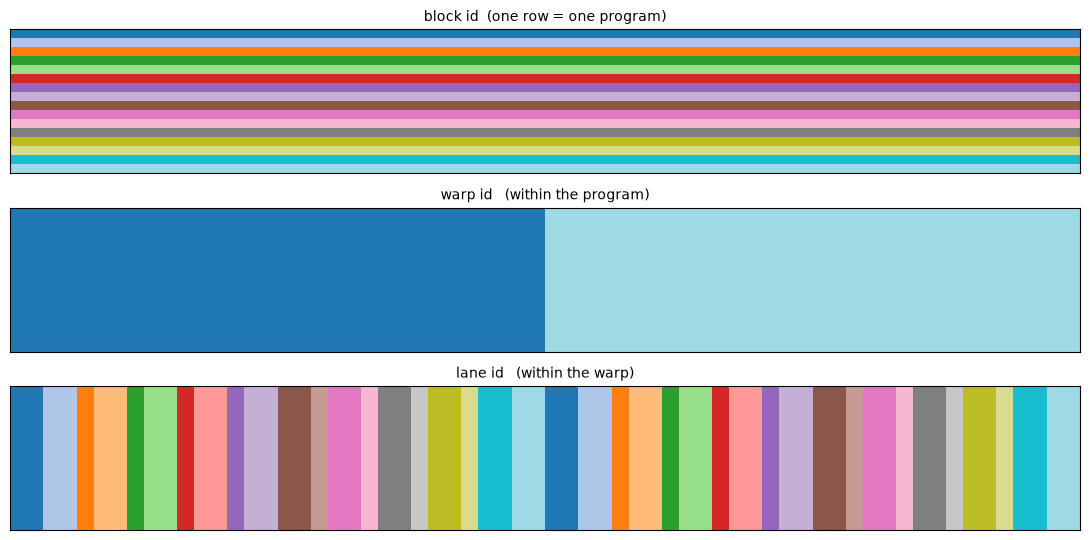

In [7]:
@triton.jit
def who_am_i(out_ptr, n, WHAT: tl.constexpr, BLOCK: tl.constexpr):
    # WHAT is tl.constexpr, so it is known at COMPILE time. Triton compiles a
    # separate kernel per value and the `if` below disappears entirely -- it is not
    # a branch the GPU evaluates, and it costs nothing at runtime. (Contrast this
    # with a branch on data, which is this section's closing subject.)
    pid  = tl.program_id(0)          # which program instance am I?
    lane = tl.arange(0, BLOCK)       # [0 .. BLOCK-1]: my positions
    offs = pid * BLOCK + lane        # the global elements I own

    if WHAT == 0:
        # `pid` is one scalar, but we must store BLOCK values. Adding a zero vector
        # broadcasts it: pid -> [pid, pid, ..., pid].
        v = pid + tl.zeros([BLOCK], tl.int32)
    elif WHAT == 1:
        v = lane // 32               # 0..31 -> 0, 32..63 -> 1 : which warp
    else:
        v = lane % 32                # 0..31, then 0..31 again : position in the warp

    tl.store(out_ptr + offs, v.to(tl.float32), mask=offs < n)

import matplotlib.pyplot as plt

# H rows x W columns, with BLOCK == W, so ONE IMAGE ROW IS EXACTLY ONE PROGRAM.
# That is the whole trick behind reading the picture.
H, W, BLOCK = 16, 64, 64
NUM_WARPS   = BLOCK // 32                          # pin it: 1 element per hardware lane
out  = torch.empty(H * W, device="cuda")
grid = (triton.cdiv(H * W, BLOCK),)                # 1024 / 64 = 16 program instances

print(f"grid {grid[0]} programs x BLOCK {BLOCK} elements"
      f" = {grid[0]*BLOCK} elements, drawn as {H}x{W}")
print(f"num_warps pinned to {NUM_WARPS}: {NUM_WARPS*32} lanes for {BLOCK} elements"
      f" -> {BLOCK//(NUM_WARPS*32)} element per lane")

fig, axes = plt.subplots(3, 1, figsize=(11, 5.5))
for ax, what, title in zip(axes, (0, 1, 2),
                           ("block id  (one row = one program)",
                            "warp id   (within the program)",
                            "lane id   (within the warp)")):
    who_am_i[grid](out, H * W, what, BLOCK=BLOCK, num_warps=NUM_WARPS)
    ax.imshow(out.reshape(H, W).cpu(), aspect="auto", cmap="tab20", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Read the three panels together. Each is the same 1,024 elements, labelled at a
different level:

* **block id** — sixteen solid horizontal bands, one per row. Each program owns one
  contiguous run of 64 elements. This is the grid.
* **warp id** — every band splits into two halves. `BLOCK = 64` at 32 lanes per warp
  is two warps, so the left half of every row is warp 0 and the right half warp 1.
* **lane id** — a 0…31 ramp that restarts halfway across every row. That restart is
  the warp boundary, and the period of the ramp is the warp width.

Stacked up, the machine your 16-program launch produced is:

```text
grid: 16 programs
 ├── program 0
 │     ├── warp 0 → lanes 0..31   → elements 0..31
 │     └── warp 1 → lanes 0..31   → elements 32..63
 ├── program 1  … same structure, elements 64..127
 └── … 14 more
```

Change `BLOCK` and re-run. The bands get wider or narrower and the number of warps
per row changes with them — but the lane ramp keeps its period of 32 whatever you
choose. **You pick the block size. You do not pick that number.**

!!! question "💬 The kernel contains an `if`. Divergence, below, will show that branches inside a warp can cost real time. Why is this one free?"

    ??? hint "Answer"
        Because `WHAT` is declared `tl.constexpr` — a **compile-time** constant. Triton
        compiles three separate kernels, one per value, and in each of them the `if` has
        already been resolved and removed. No branch survives to run on the GPU. The
        expensive case below is the opposite: a branch on *data*, whose value
        differs between lanes of the same warp and therefore cannot be resolved until
        the kernel is executing.

### SIMT: SIMD with the vector hidden

An AVX2 instruction on a CPU operates on eight float lanes at once:

```text
one instruction
      │
      ▼
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │
└─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┘
```

You explicitly program vectors, or rely on the compiler to generate them.

GPU programming hides the vector. You write scalar code:

```text
thread 0: C[0] = A[0] + B[0]
thread 1: C[1] = A[1] + B[1]
thread 2: C[2] = A[2] + B[2]
...
```

The hardware groups the threads:

```text
32 threads
      │
      ▼
one instruction
      │
      ▼
32 lanes execute together
```

This is **SIMT — Single Instruction, Multiple Threads**. The programming interface
looks like independent scalar threads. The hardware executes them in groups.

> **SIMT is SIMD with the vector hidden.**

That gap between the programming model and the hardware is responsible for several
important GPU performance effects — and for the correction that follows.

### A CUDA core is not a core

"2,304 cores" invites a misleading picture:

```text
2,304 tiny CPUs
```

That is not what the GPU contains. There are compute units that contain scheduling
and control machinery, and thousands of arithmetic lanes that those units drive.

A CUDA core / shader ALU is therefore better thought of as:

> **one arithmetic lane, not one independent processor.**

It has no independent program counter and cannot fetch and execute an independent
program. Prefer `2,304 FP32 ALUs` over `2,304 cores` when describing what the
silicon actually contains.

!!! question "💬 If a CUDA core is not a core, what *is* the smallest thing on a GPU that has its own program counter?"

    ??? hint "Answer"
        The **warp**, not the thread and certainly not the lane. A warp has one instruction stream and one program counter shared by its 32 lanes. That single fact is the source of both of the effects in this lecture: divergence (when lanes disagree about where the program counter should go) and the cheapness of warp switching (when the scheduler picks a different warp's program counter).

### Measure the warp width instead of looking it up

You can ask the driver for the warp size — `torch.cuda.get_device_properties(0).warp_size`.
That is looking up the answer. You can also make the hardware confess it.

Give each block exactly **one warp** (`num_warps=1`) and then vary how many
elements that block is asked to process. If threads were independent, halving the
block size should halve the work per block and cost half the time. If the hardware
really issues in groups of 32, then any block with 32 or fewer elements occupies a
whole warp anyway — and the unused lanes cost nothing, because they were never
free to begin with.

In [8]:
@triton.jit
def fixed_work(x_ptr, o_ptr, n, BLOCK: tl.constexpr, ITERS: tl.constexpr):
    offs = tl.program_id(0) * BLOCK + tl.arange(0, BLOCK)
    m = offs < n
    y = tl.load(x_ptr + offs, mask=m, other=0.0)
    for _ in range(ITERS):
        y = tl.maximum(y * 1.0000001 + 1.0, 0.0) * 0.9999   # not an affine recurrence:
    tl.store(o_ptr + offs, y, mask=m)                        # the compiler cannot close-form it

n = 1 << 18
x = torch.randn(n, device="cuda"); o = torch.empty_like(x)

print(f"{'BLOCK':>7} {'blocks':>8} {'ms':>9} {'Melem/s':>10} {'speedup':>9}")
base = None
for blk in (1, 2, 4, 8, 16, 32, 64, 128):          # not `B` -- that is one of our matrices
    g = (triton.cdiv(n, blk),)
    ms = triton.testing.do_bench(
        lambda: fixed_work[g](x, o, n, BLOCK=blk, ITERS=256, num_warps=1),
        warmup=25, rep=200, return_mode="median")
    thr = n / (ms * 1e-3) / 1e6
    base = base or thr
    print(f"{blk:>7} {g[0]:>8} {ms:>9.3f} {thr:>10.1f} {thr/base:>8.1f}x")

  BLOCK   blocks        ms    Melem/s   speedup


      1   262144     1.309      200.2      1.0x
      2   131072     0.652      402.2      2.0x


      4    65536     0.321      815.6      4.1x


      8    32768     0.166     1575.0      7.9x
     16    16384     0.092     2851.8     14.2x


     32     8192     0.052     5033.4     25.1x
     64     4096     0.052     5064.6     25.3x


    128     2048     0.052     5033.4     25.1x


Measured on the course laptop (RX 6700M, wave32, ROCm 7.2, Triton 3.7.1):

```text
BLOCK   blocks        ms    Melem/s   speedup
      1   262144     1.309      200.2      1.0x
      2   131072     0.652      402.2      2.0x
      4    65536     0.321      815.6      4.1x
      8    32768     0.166     1575.0      7.9x
     16    16384     0.092     2851.8     14.2x
     32     8192     0.052     5033.4     25.1x
     64     4096     0.052     5064.6     25.3x
    128     2048     0.052     5033.4     25.1x
```

Two regimes, and the boundary between them is the whole point.

Below 32, **each extra thread is free**: every doubling of `BLOCK` doubles the
throughput, because those lanes were sitting in the warp doing nothing. From 32
onward the throughput stops improving entirely — 32, 64 and 128 land within 1% of
each other — because the warp is now full and any further work has to be issued as
extra instructions.

> **The knee is the warp width. You just measured it without asking the vendor.**

!!! question "💬 A colleague launches blocks of 8 threads because their problem has 8 lanes of work and they want to 'use less of the GPU'. What fraction of the machine are they actually paying for?"

    ??? hint "Answer"
        **All of it.** A block of 8 threads still occupies a full 32-lane warp — the
        table shows a block of 8 running at 7.9× the throughput of a block of 1, while a
        block of 32 reaches 25.1×. They are being billed for 32 lanes and using 8. This
        is also why the wavefront width in [Appendix B](#appendix-b-this-laptops-gpus)
        matters: the same code on this laptop's integrated GPU is billed in units of 64.

### The price of SIMT: divergence

The warp bargain sends you a bill. Consider:

```cpp
if (x > 0)
    a();
else
    b();
```

Suppose exactly half of a 32-thread warp takes each branch. The hardware cannot
execute both paths simultaneously, because the warp shares one instruction stream
and one program counter. Instead:

```text
if (x[i] > 0) { A; } else { B; }        time →
  lanes with x>0 :  ██ A ██  ░░ idle ░░
  lanes with x≤0 :  ░░ idle ░░  ██ B ██     ← ½ speed here; 1/32 worst case
```

Both paths execute. Every lane is occupied during both passes, but half of the
lanes are inactive during each pass. This is **warp divergence**.

Matmul, incidentally, is beloved by the hardware partly because every thread runs
the identical multiply-add sequence — **zero divergence, ever**.

#### Divergence is per warp

Divergence is not determined by whether a branch exists. It depends on whether
threads **within the same warp** disagree. For example:

```cpp
if (tid < 32)
```

If the warp is aligned with those 32 threads, every thread in the warp agrees. No
divergence. But:

```cpp
if (tid % 2)
```

splits every warp into two groups, and both paths execute. Same branch syntax.
Very different hardware cost. The extreme case is a 32-way split:

```text
32 different paths
        ↓
32 sequential executions
```

#### But divergence does not automatically mean slower

!!! question "💬 A divergent kernel issues roughly twice the instructions of the non-divergent one. Predict the slowdown."

    ??? hint "Answer"
        **About 1.08×**, not 2×. Measured on the RX 6700M:

        ```text
        warp agrees, one path runs           :   1.200 ms
        warp splits on (lane % 2)            :   1.297 ms
        2x instructions, one dependent chain :   2.543 ms
        ```

        Doubling the instructions *along a dependent chain* costs 2.12×. Doubling them *across two independent paths* costs 1.08×. The instruction count is identical in both cases — so instruction count is not what you are being billed for.

The single-path kernel was a long dependent chain: each operation depended on the
result of the previous one, so many issue opportunities were already going unused.
The divergent kernel added another *independent* path, whose extra instructions
could occupy those otherwise-empty slots.

```text
single path:              divergent:
    useful instruction        path A instruction
    wait                      path B instruction
    useful instruction        path A instruction
    wait                      path B instruction
    ...                       ...
```

> **Divergence bills you in issue slots. Whether that costs you time depends on
> whether the machine had spare slots.**

Stated more generally, and worth carrying beyond GPUs:

> **Instruction count is not execution time.**

This is why "avoid all branches on GPUs" is bad advice. Measure the kernel.

---

## Depth 5 — One block, one tile of C

We can now cash in the kernel name from Depth 1.

The vector add was one-dimensional and each element was independent. A matmul is
neither: every element of `C` is a dot product over a whole row and column. The
decomposition is the same idea in two dimensions, and it requires one change of
mental model:

> **Stop thinking "one thread = one element of C". Think "one block = one tile of
> C".**

That is not a stylistic preference. A block is pinned to one compute unit, which
is what makes its shared memory and barriers usable — so a block is the largest
group of threads that can *cooperate* on a piece of `C`. Cutting `C` into tiles
and giving one block to each tile is the decomposition the hardware is shaped for.

C is 512x512, tile 128x64  ->  grid (4, 8) = 32 blocks


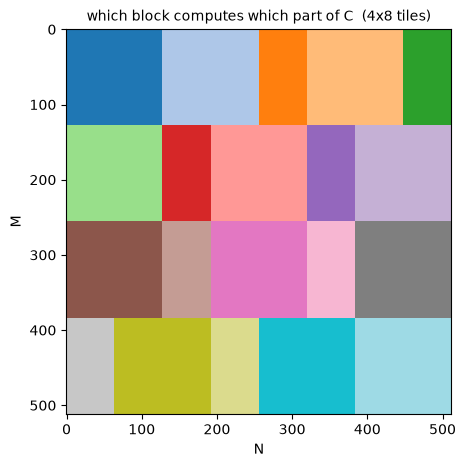

In [9]:
@triton.jit
def tile_map(out_ptr, M, N, BM: tl.constexpr, BN: tl.constexpr):
    pid_m, pid_n = tl.program_id(0), tl.program_id(1)      # a 2-D grid, one block per tile
    rm = pid_m * BM + tl.arange(0, BM)
    rn = pid_n * BN + tl.arange(0, BN)
    v  = pid_m * tl.cdiv(N, BN) + pid_n                    # this block's id
    tl.store(out_ptr + rm[:, None] * N + rn[None, :],
             (v + tl.zeros([BM, BN], tl.int32)).to(tl.float32),
             mask=(rm[:, None] < M) & (rn[None, :] < N))

M = N = 512
BM, BN = 128, 64                                           # the tile the library chose, below
out  = torch.empty((M, N), device="cuda")
grid = (triton.cdiv(M, BM), triton.cdiv(N, BN))
tile_map[grid](out, M, N, BM=BM, BN=BN)

print(f"C is {M}x{N}, tile {BM}x{BN}  ->  grid {grid} = {grid[0]*grid[1]} blocks")
plt.figure(figsize=(5, 5))
plt.imshow(out.cpu(), cmap="tab20", interpolation="nearest")
plt.title(f"which block computes which part of C  ({grid[0]}x{grid[1]} tiles)", fontsize=10)
plt.xlabel("N"); plt.ylabel("M"); plt.show()

That picture is the grid. Now read the real one off the kernel name from the top of
the lecture — it tells you the tile the vendor's library picked for your matmul:

In [10]:
import re

def decode(name, warp=WARP):
    """Pull the decomposition out of a vendor GEMM kernel name.

    ROCm/Tensile spells it out: MT<m>x<n>x<k> macro tile, WG<x>_<y>_<z> workgroup,
    TT<m>_<n> per-thread tile, WS<w> wave size. cuBLAS is terser -- `sgemm_128x64`
    -- and gives only the tile. Anything else, we say so rather than guess.
    """
    mt = re.search(r"MT(\d+)x(\d+)x(\d+)", name) or re.search(r"gemm_(\d+)x(\d+)", name)
    wg = re.search(r"WG(\d+)_(\d+)_(\d+)", name)
    tt = re.search(r"TT(\d+)_(\d+)", name)
    ws = re.search(r"WS(\d+)", name)
    if not mt:
        print("could not find a tile shape in this kernel name -- print it and look yourself")
        return
    bm, bn = int(mt.group(1)), int(mt.group(2))
    M, N = MATMUL_SHAPE
    gm, gn = -(-M // bm), -(-N // bn)              # ceiling division
    print(f"tile of C per block   : {bm} x {bn}   = {bm*bn:,} outputs")
    print(f"grid                  : {gm} x {gn} = {gm*gn:,} blocks")
    if ws: print(f"wave size (hardware)  : {ws.group(1)}")
    if wg:
        thr = int(wg.group(1)) * int(wg.group(2)) * int(wg.group(3))
        print(f"threads per block     : {wg.group(1)}x{wg.group(2)}x{wg.group(3)} = {thr}"
              f"  -> {thr // int(ws.group(1) if ws else warp)} warps per block")
        if tt:
            tm, tn = int(tt.group(1)), int(tt.group(2))
            print(f"outputs per thread    : {tm} x {tn} = {tm*tn}")
            print(f"check                 : {thr} threads x {tm*tn} = {thr*tm*tn:,}"
                  f"  vs tile {bm*bn:,}  -> {'consistent' if thr*tm*tn == bm*bn else 'MISMATCH'}")

decode(MATMUL_KERNEL)

tile of C per block   : 128 x 64   = 8,192 outputs
grid                  : 16 x 32 = 512 blocks
wave size (hardware)  : 32
threads per block     : 16x8x1 = 128  -> 4 warps per block
outputs per thread    : 8 x 8 = 64
check                 : 128 threads x 64 = 8,192  vs tile 8,192  -> consistent


On the course laptop, for the 2048×2048 matmul at the top of this lecture:

```text
tile of C per block   : 128 x 64   = 8,192 outputs
grid                  : 16 x 32 = 512 blocks
wave size (hardware)  : 32
threads per block     : 16x8x1 = 128  -> 4 warps per block
outputs per thread    : 8 x 8 = 64
check                 : 128 threads x 64 = 8,192  vs tile 8,192  -> consistent
```

That is the complete answer to the question this lecture opened with. One line of
PyTorch became **512 blocks × 4 warps = 2,048 warps, 65,536 threads**, each thread
responsible for an 8×8 patch of `C`, and the arithmetic closes exactly.

Nothing here was a slide. Every one of those numbers came out of the string the
profiler printed for the line *you* wrote.

Notice the last two lines especially. Each thread does not compute one output — it
computes **64**, an 8×8 patch it keeps in registers. That is a second level of
tiling below the block, and it is the reason the register file has to be as large
as it is. Depth 3's budget and Depth 5's decomposition are the same constraint seen
from two ends.

!!! question "💬 Re-run the profiler on a much smaller matmul — say 256×256. Does the library pick the same tile?"

    ??? hint "Answer"
        No. On the course laptop a two-layer MLP's `nn.Linear` calls select
        `MT64x64x8` with `WG16_16_1` (256 threads = 8 warps) and `TT4_4`, and the check
        still closes: 256 × 16 = 4,096 = 64 × 64. The library keeps a library of tilings
        and picks one per problem shape, because the best decomposition depends on
        whether you have enough tiles to fill every CU and enough work per tile to be
        worth the launch. That trade-off is the subject of [Lecture 8](Lecture8.md).

---

## Occupancy: the budget on residency

Latency hiding needs resident warps. Resident warps consume resources. Occupancy
is the name of that trade.

The main budgets are registers, shared memory, maximum resident waves, maximum
threads, and architectural limits per block. They interact in one direction:

```text
more registers per thread          more shared memory per block
        ↓                                  ↓
fewer threads fit                  fewer blocks fit on a CU
        ↓                                  ↓
fewer resident warps               fewer resident warps
        ↓
fewer candidates for the scheduler
        ↓
less latency hiding
```

On this GPU:

```text
32 waves per CU
64 KB LDS per workgroup
```

A block requesting 32 KB of shared memory is therefore limited to `64 / 32 = 2`
blocks resident per CU, even if registers would allow more.

### Is low occupancy bad?

Suppose a profiler reports **25% occupancy**. Is that automatically a problem?

No. Occupancy is only one ingredient in latency hiding. The real goal is:

> **Have enough independent work in flight to cover the latency generated by this
> kernel.**

A kernel with high arithmetic intensity, lots of instruction-level parallelism and
many registers per thread may run very well at low occupancy. Reducing register
usage simply to raise occupancy can even make things worse, if it causes register
spills to memory.

> **Occupancy is a diagnostic to read when something is slow, not a score to
> maximize.**

This is also the trade-off that produced the hundreds of pre-compiled BLAS kernels
we met in Depth 1. Fatter tiles mean more reuse per byte fetched, but fewer
resident warps to hide latency with. They compete for the same silicon, the best
compromise depends on the shape, and so the vendor ships one kernel per point on
that curve and picks between them at call time.

---

## What lies below

The descent has three depths left, and all of them are about *feeding* the machine
we just built. They are [Lecture 8](Lecture8.md):

* **Depth 6 — coalescing and broadcast.** DRAM cannot hand out single floats; it
  serves 128-byte lines. So the memory system inspects a warp's 32 lockstep
  addresses *as a group*. Neat and adjacent → one transaction. Scattered → up to 32
  transactions for the same instruction. This is the same warp we just met, seen
  from the memory side.
* **Depth 7 — the hierarchy and the FLOPs/byte wall.** Registers, shared memory,
  L2, DRAM. Arithmetic capacity has outgrown bandwidth so far that a modern GPU
  needs *hundreds* of floating-point operations per byte fetched to stay busy — and
  a naive matmul manages about one. Latency hiding cannot help here: it hides
  *latency*, not missing *bandwidth*. Tiling is what breaks that wall, and the
  tile you decoded in Depth 5 is the tool.
* **Depth 8 — tensor cores and `torch.compile`.** Casting matmul into dedicated
  wiring, and removing the round-trips to slow memory between kernels.

One organizing principle sits underneath all three, and it is worth carrying out of
this lecture even before you meet the evidence:

> **Arithmetic is nearly free; moving data is expensive. Every layer of this stack
> is an arrangement for touching slow memory as rarely as possible** — coalescing
> per instruction, tiling per block, register micro-tiles per thread, fusion per
> graph.

---

## Synthesis: the whole descent

```text
C = A @ B
   │
   │  CPU-side, ~159 µs of paperwork (measured, Depth 1)
   │  dispatcher (keys: CUDA, fp32) → BLAS heuristic → kernel pick
   ▼
launch → command queue → doorbell (MMIO write) → CPU RETURNS
   │                              …async: the math has not happened yet
   ▼
the work distributor drops 512 blocks onto 18 units, in waves
   │
   ▼  on each compute unit:
block = one 128×64 tile of C, pinned here, 4 warps
   each thread owns an 8×8 patch of C, held in registers
   │
   ├── warps issue in lockstep, 32 lanes per instruction fetch   (Depth 4)
   ├── a warp that stalls on DRAM simply becomes ineligible      (Depth 3)
   └── the scheduler picks another resident warp — free, because
       its registers never left the register file
   │
   ▼
tile written back · block retires · next block in the wave
   │
   ▼
torch.cuda.synchronize() — the CPU finally looks at the finish line
```

The GPU keeps thousands of ALUs busy by keeping thousands of threads *resident* and
switching between them for free whenever one stalls. Everything else in this
lecture followed from that: the enormous register file, the warp as the unit of
scheduling, the divergence bill, the occupancy budget.

```text
many ALUs
    ↓
many resident warps
    ↓
cheap warp switching
    ↓
latency hiding
```

But we have only solved half of the problem. We have explained what the GPU does
**while it waits for data**. We have not asked where that data comes from, or
whether the memory system can supply it fast enough to keep this machine fed.

> **Next — [Lecture 8](Lecture8.md): memory, bandwidth, and the roofline — and why
> LLM decode is memory-bound while training on the same GPU is compute-bound.**

---

## Capstone exercise

You are running `y = torch.relu(A @ B + bias)`, with M = N = K = 4096. Predict
each result **first**, then verify it with `torch.profiler` and the cells on this
page — and name the layer of the descent that explains it.

1. **Time it with and without `torch.cuda.synchronize()`.** Explain the two
   numbers to someone who has never heard the word "asynchronous". *(Depth 1: the
   doorbell.)*
2. **Shrink M from 4096 to 8.** The FLOPs drop by 512×. Does the runtime?
   *(Depth 3: waves, residency, launch overhead — the GPU cannot fill itself.)*
3. **Profile it and decode the kernel name.** How many blocks, warps and threads
   did your `@` actually launch, and does `threads × outputs-per-thread` equal the
   tile? *(Depth 5.)*
4. **Switch fp32 → fp16.** How much faster, and is the speed-up more or less than
   2×? Explain which part of your answer this lecture can account for and which
   part needs [Lecture 8](Lecture8.md). *(Depths 5 and 8 — bytes per element meets
   the bandwidth wall.)*

If you can predict all four and be roughly right, you own this part of the stack.

---

## Run it yourself

Inspect your GPU:

```shell
rocminfo
# or
nvidia-smi -q
```

Inspect clock levels on Linux/AMD:

```shell
cat /sys/class/drm/card*/device/pp_dpm_sclk
cat /sys/class/drm/card*/device/pp_dpm_mclk
```

Run the divergence and coalescing benchmark:

```shell
python code/gpu_internals/warp_costs.py
```

The benchmark code:
[`code/gpu_internals/warp_costs.py`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_internals).
It is written in Triton so it runs across NVIDIA and AMD hardware, and on a free
Colab or Kaggle GPU.

Every code cell on this page runs the same way. If you would rather execute them
than read them, open the notebook built from this page with the Colab badge at the
top, or generate it locally:

```shell
make notebooks        # jupytext: this page -> docs/lectures/Lecture7.ipynb
make notebooks-exec   # ...and run every cell on your own GPU
```

On an AMD RDNA2 laptop GPU you may need `HSA_OVERRIDE_GFX_VERSION=10.3.0` in the
environment before PyTorch will see the card.

---

## Appendix A — NVIDIA and AMD terminology

| NVIDIA                        | AMD / ROCm                    |
| ----------------------------- | ----------------------------- |
| SM — Streaming Multiprocessor | CU — Compute Unit             |
| warp                          | wavefront                     |
| CUDA core                     | stream processor / shader ALU |
| shared memory                 | LDS — Local Data Share        |
| thread block                  | workgroup                     |
| warp scheduler                | SIMD scheduler                |
| tensor core                   | matrix core                   |

The exact internal organization differs between architectures, so these should be treated as corresponding concepts rather than literally identical hardware.

The names differ, but the important concepts are:

```text
many arithmetic lanes
        +
thread groups
        +
resident state
        +
scheduler
        +
fast local memory
        +
large-bandwidth memory
```

---

## Appendix B — This laptop's GPUs

`rocminfo` reports two GPUs in the same machine:

|                  | RX 6700M | Integrated Radeon Graphics |
| ---------------- | -------: | -------------------------: |
| Compute Units    |       36 |                          8 |
| SIMDs per CU     |        2 |                          4 |
| Wavefront size   |       32 |                         64 |
| Max waves per CU |       32 |                         40 |

The same laptop therefore contains two AMD GPUs with different wavefront widths.

This is a useful reminder:

> **A warp/wavefront width is an architectural design choice, not a universal law.**

Code that blindly assumes one particular width is making a hardware assumption.

---

## References and further reading

**The descent, made runnable**

1. Simon Boehm, [*How to Optimize a CUDA Matmul Kernel*](https://siboehm.com/articles/22/CUDA-MMM) — the classic worklog: from the naive kernel to near-cuBLAS speed in ten steps. Everything on this page, as code.
2. Horace He, [*Making Deep Learning Go Brrrr From First Principles*](https://horace.io/brrr_intro.html) — the compute-bound / memory-bound / overhead-bound trichotomy, from a PyTorch compiler author.
3. Edward Yang, [*Let's Talk About the PyTorch Dispatcher*](http://blog.ezyang.com/2020/09/lets-talk-about-the-pytorch-dispatcher/) — the authoritative walkthrough of Depth 1: dispatch keys, and how one op name finds its implementation.

**The execution model**

4. NVIDIA, [*CUDA C++ Programming Guide*](https://docs.nvidia.com/cuda/cuda-c-programming-guide/) — the primary source for grids, warps, shared memory, divergence and occupancy.
5. AMD, [*RDNA 2 Instruction Set Architecture Reference Guide*](https://gpuopen.com/amd-gpu-architecture-programming-documentation/) — compute units, wavefronts, vector register file.
6. Hwu, Kirk & El Hajj, *Programming Massively Parallel Processors* — the standard textbook; chapters 4–6 cover SIMT, memory and tiling in full rigor.
7. [Triton documentation](https://triton-lang.org)
8. [GPU MODE lecture series](https://github.com/gpu-mode/lectures) — community lectures from practitioners: profiling, Triton, and modern kernel work.

**Course material**

9. Vijay Janapa Reddi, [*Machine Learning Systems*](https://mlsysbook.ai) — Ch. 11: AI Acceleration
10. Course code: [`code/gpu_internals`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_internals)